<a href="https://colab.research.google.com/github/Rakshay94/Deta-analyst-pw-skills-/blob/ML/customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully!

Generating a synthetic dataset with 7000 samples...
Synthetic dataset saved to: /content/../data/synthetic_telco_churn_data.csv

First 5 rows of the dataset:
     customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0  8270-535-960  Female              1     Yes         No      36   
1  6390-206-171  Female              0     Yes         No      27   
2  6734-221-566    Male              1     Yes         No      17   
3  5426-558-187    Male              0      No         No      41   
4  9322-761-408  Female              1      No         No       4   

  PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
0          Yes               Yes             DSL                  Yes  ...   
1          Yes                No             DSL  No internet service  ...   
2          Yes               Yes              No  No internet service  ...   
3           No  No phone service     Fiber optic                  Yes  ...   
4  

<ipython-input-13-2643623489>:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


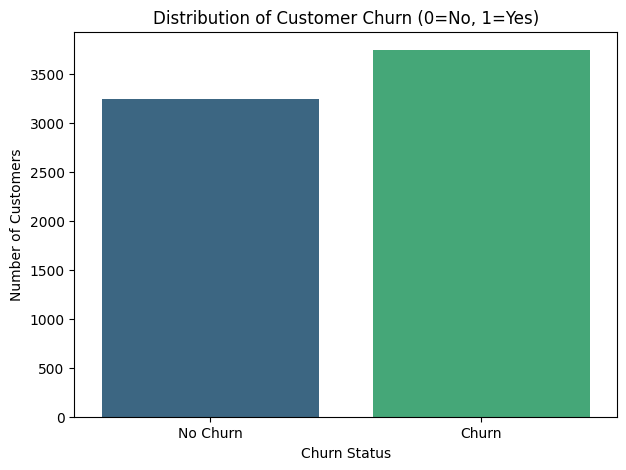

Interpretation: This plot shows the imbalance in the target variable. There are typically more non-churning customers than churning ones.

Analyzing categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


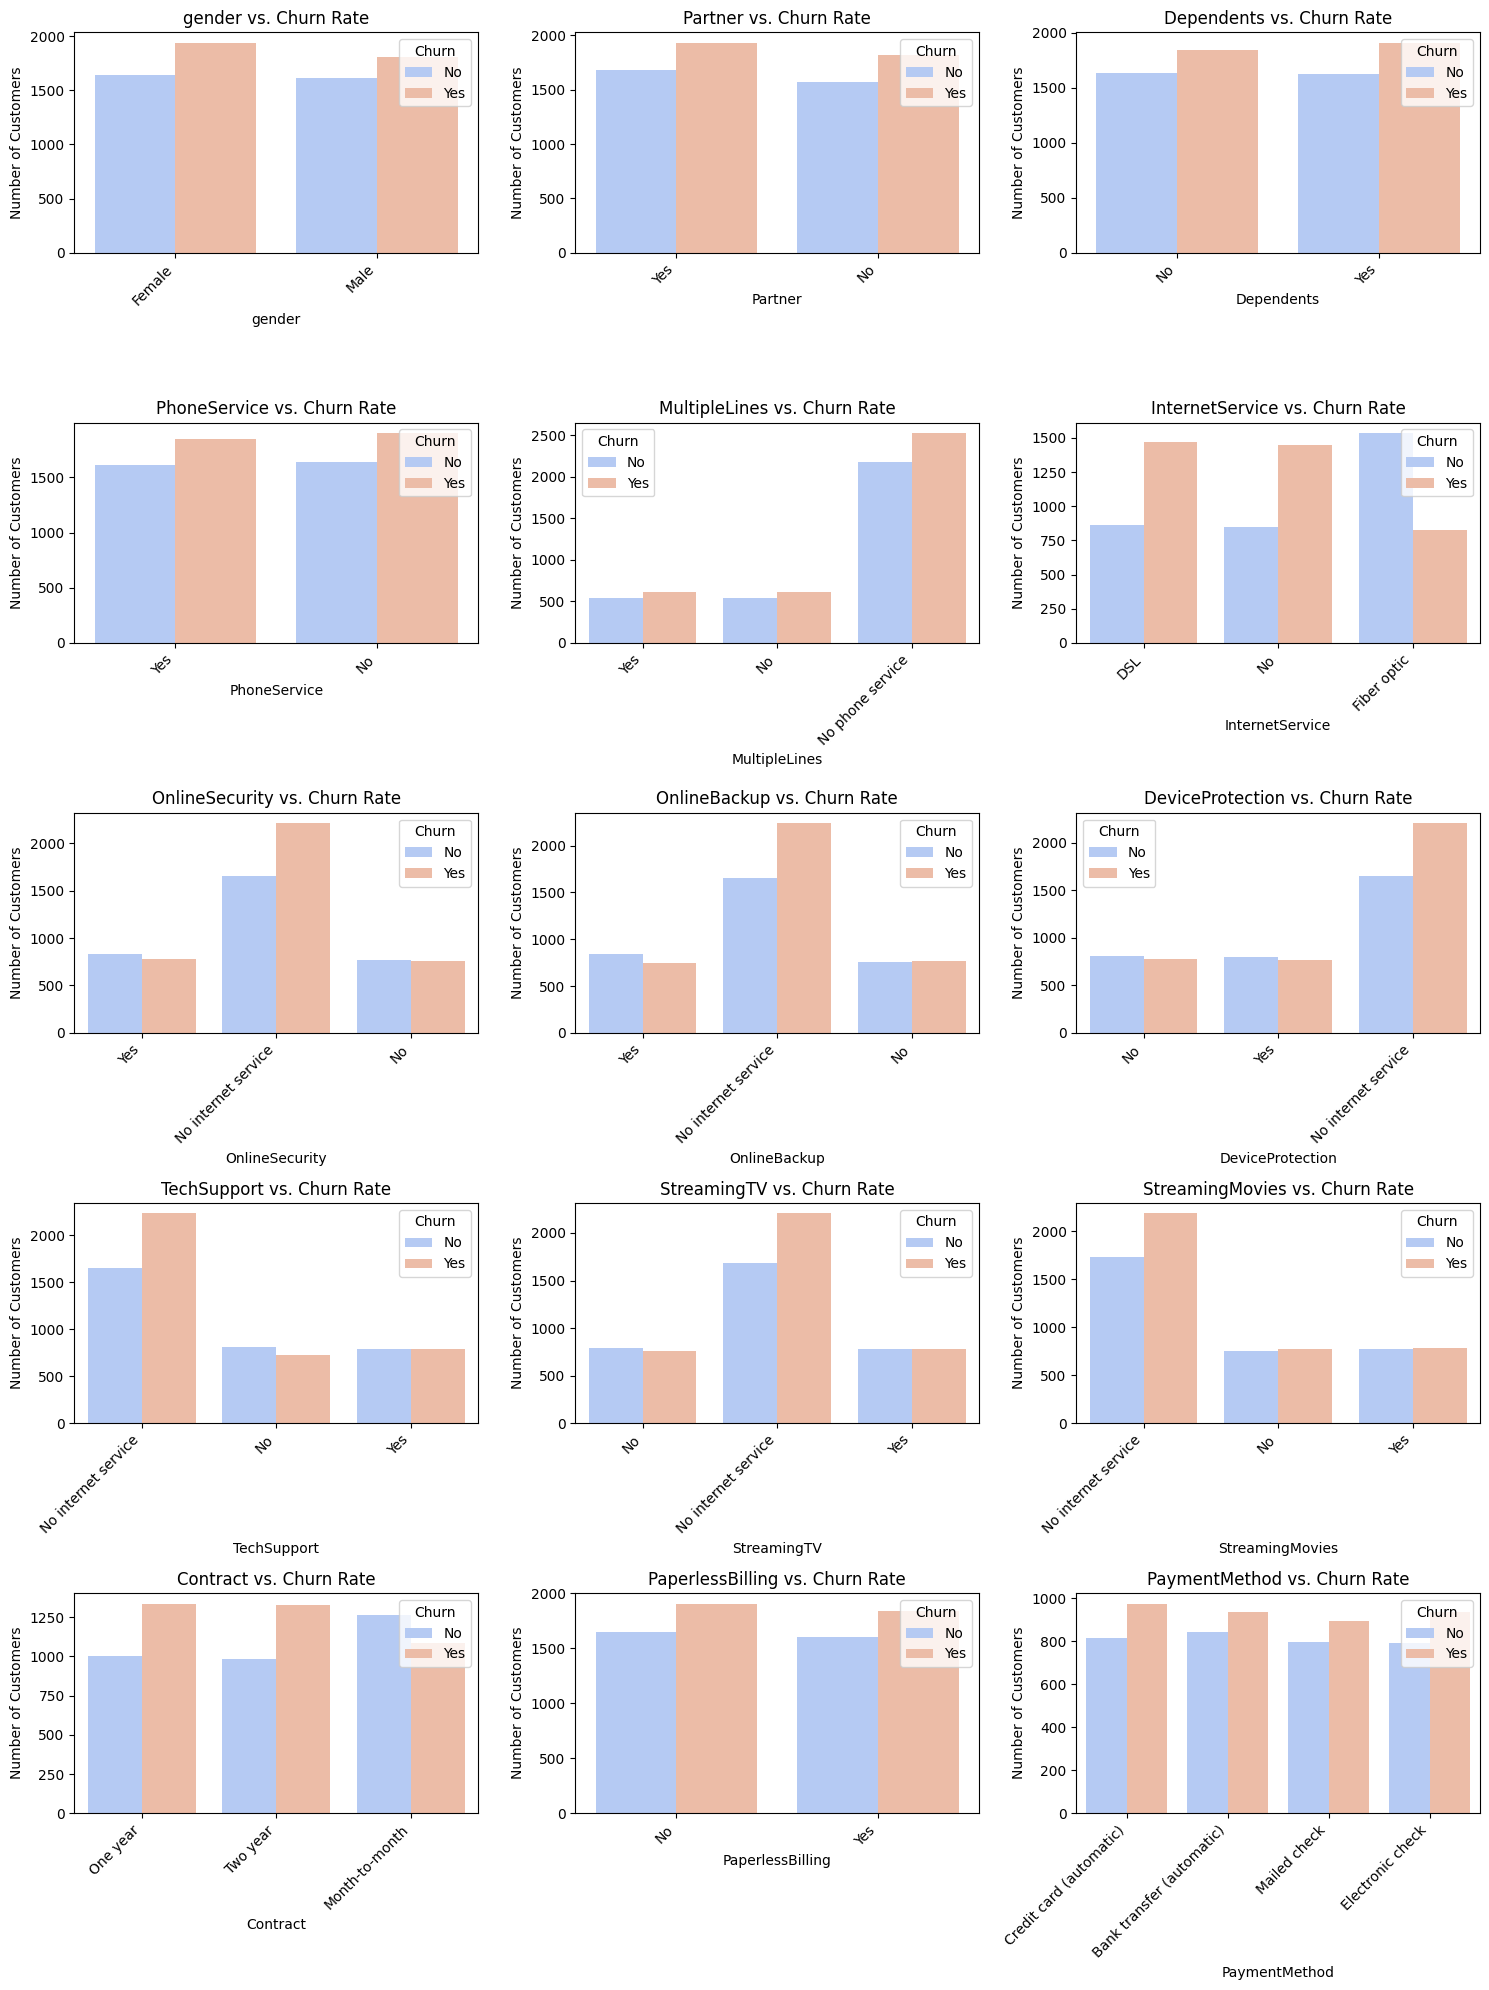

Interpretation of Categorical Plots:
- **Contract Type:** Observe how 'Month-to-month' contracts often have a disproportionately higher churn rate compared to 'One year' or 'Two year' contracts. This is a crucial business insight!
- **Internet Service:** 'Fiber optic' customers might show higher churn, possibly due to perceived quality issues or higher cost compared to DSL.
- **OnlineSecurity, TechSupport:** Customers without these services (or 'No internet service') might have higher churn, indicating these are key retention factors.
- **Payment Method:** 'Electronic check' often has higher churn, possibly linked to less stable customer segments.

Analyzing numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']


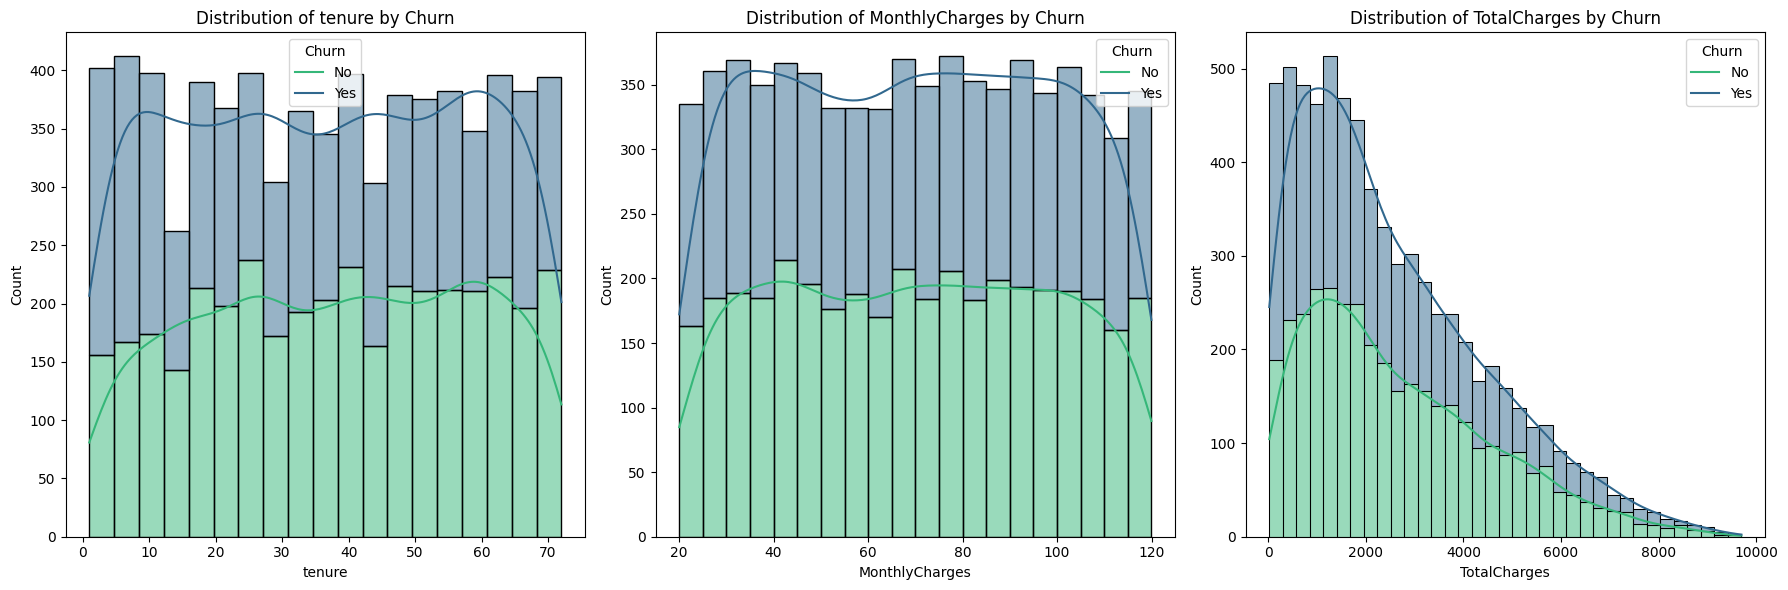

Interpretation of Numerical Plots:
- **Tenure:** Shorter tenure (customers who have been with the company for fewer months) shows a higher concentration of churning customers. This suggests that new customers are more prone to churn.
- **MonthlyCharges:** Customers with higher monthly charges, especially those on Fiber Optic plans, might have higher churn rates. This could indicate price sensitivity.
- **TotalCharges:** Similar to tenure, lower total charges (implying shorter tenure or lower services) correlates with higher churn.

Correlation matrix for numerical features and Churn:
                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000       -0.009149      0.749285  0.080938
MonthlyCharges -0.009149        1.000000      0.542962  0.007761
TotalCharges    0.749285        0.542962      1.000000  0.068287
Churn           0.080938        0.007761      0.068287  1.000000


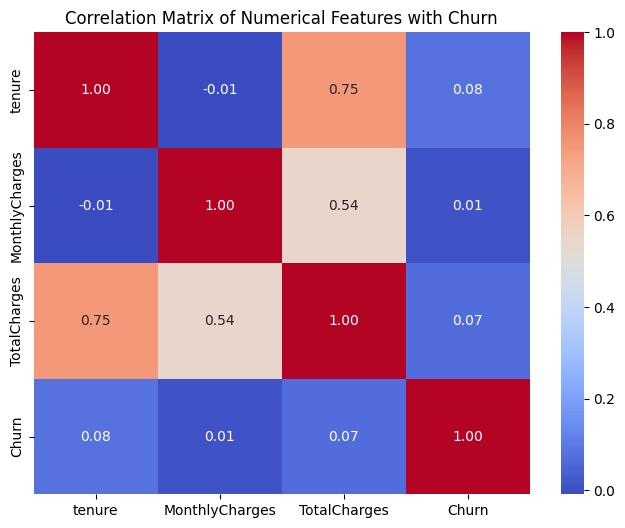

Interpretation: 'tenure' and 'TotalCharges' show a negative correlation with 'Churn' (as they increase, churn tends to decrease), while 'MonthlyCharges' shows a positive correlation (higher charges, higher churn). This confirms visual insights.

--- Starting Data Preprocessing ---
Features (X) shape: (7000, 19), Target (y) shape: (7000,)

Identified Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Identified Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessing transformers (StandardScaler, OneHotEncoder) defined.

Training data shape: (5600, 19), Test data shape: (1400, 19)
Churn distribution in training set:
Churn
1    0.535357
0    0.464643
Name: proportion, dtype: float64
Churn distribution in test set:
Churn
1    0.535714
0    0.

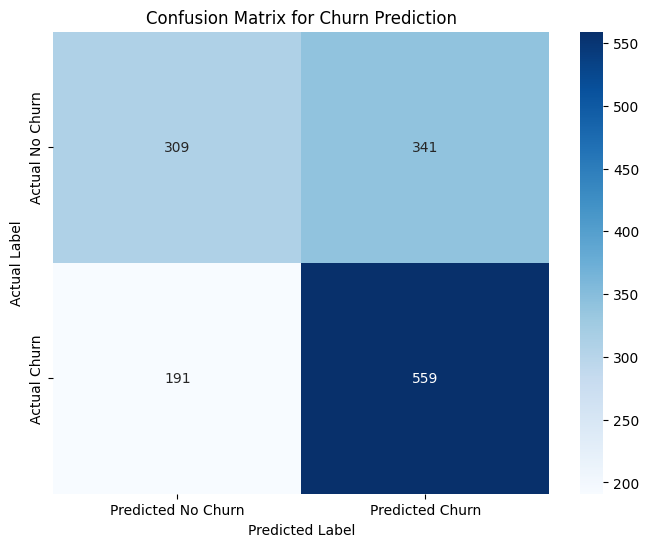

Interpretation of Evaluation Metrics & Confusion Matrix:
- **True Positives (TP):** Top-left (or bottom-right, depending on labels) - Correctly predicted 'No Churn'.
- **False Positives (FP):** Top-right - Predicted 'Churn', but customer actually 'Did Not Churn' (Type I error).
- **False Negatives (FN):** Bottom-left - Predicted 'No Churn', but customer actually 'Churned' (Type II error).
- **True Negatives (TN):** Bottom-right (or top-left) - Correctly predicted 'Churn'.
For churn prediction, **recall** is often very important: minimizing false negatives (missing actual churners) allows timely intervention.

--- Starting Feature Importance Analysis ---
Accessed Logistic Regression model from the pipeline.
Total features after preprocessing: 45

--- Feature Importance (Top 20 based on absolute coefficient magnitude) ---
Positive coefficients indicate features that INCREASE the likelihood of churn.
Negative coefficients indicate features that DECREASE the likelihood of churn.

Note: For

<ipython-input-13-2643623489>:416: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df.head(20), palette='viridis')


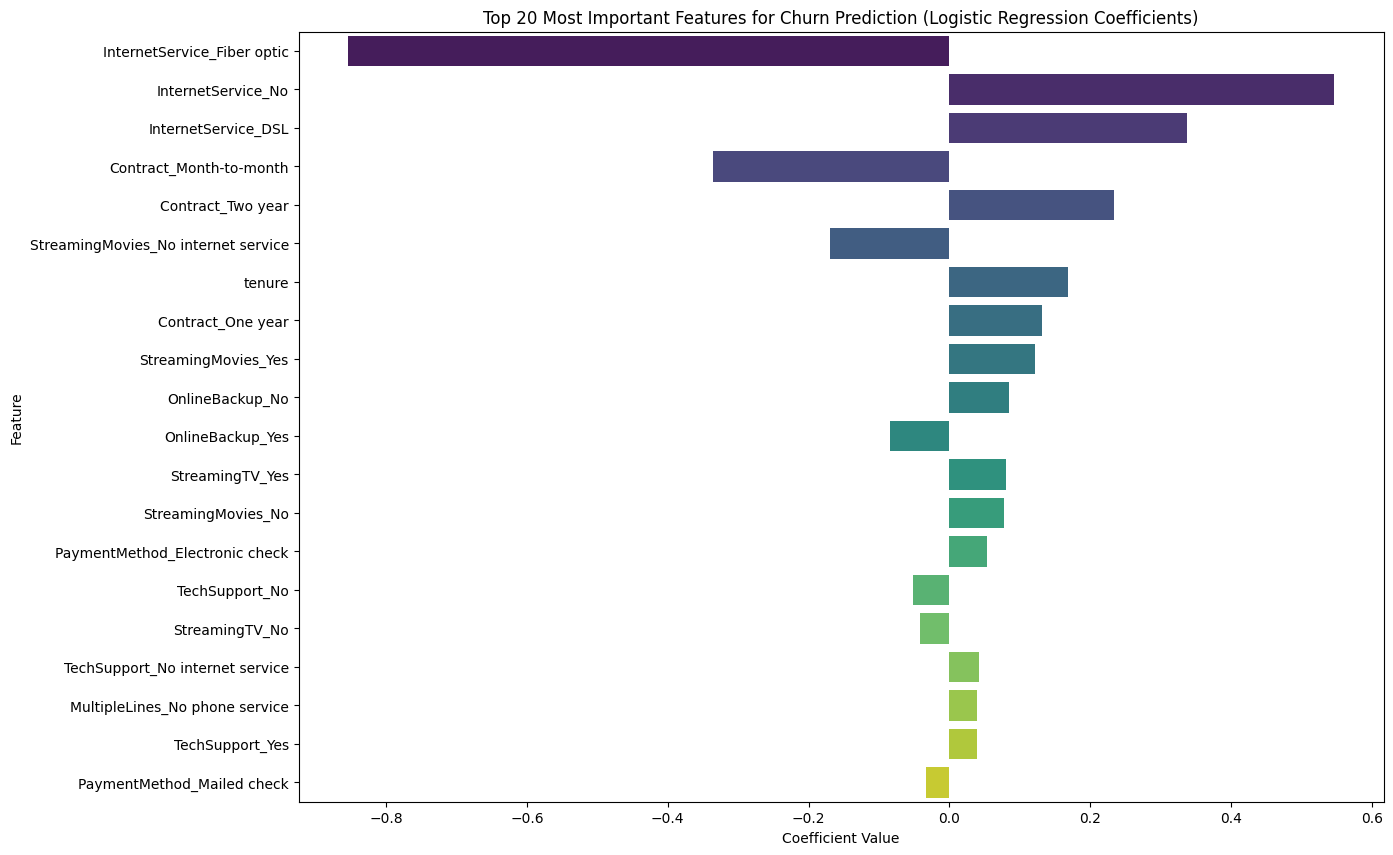


Interpretation of Feature Importance:
- **Contract_Month-to-month:** Expect a large positive coefficient. This means customers on a month-to-month contract are much more likely to churn compared to those on longer contracts (the baseline). This is a critical actionable insight for marketing and retention teams.
- **tenure:** Expect a negative coefficient. As tenure increases, the likelihood of churn decreases. Longer-term customers are more loyal.
- **InternetService_Fiber optic:** Expect a positive coefficient. Fiber optic customers might be more prone to churn, potentially due to higher prices or service issues specific to that technology.
- **OnlineSecurity_No / TechSupport_No:** Expect positive coefficients. Customers lacking these security/support features are more likely to churn, indicating their importance for customer satisfaction.
- **TotalCharges:** Expect a negative coefficient. Higher total charges (often correlated with longer tenure) typically indicate a more committed 

"\n## Conclusion and Actionable Insights\n\nThis project successfully built a Logistic Regression model to predict customer churn using a synthetic dataset. The evaluation metrics provide a quantitative understanding of the model's performance. More importantly for data analysts, the analysis of feature coefficients offers direct, actionable insights.\n\n**Key insights for business strategy (based on typical churn drivers observed in such datasets):**\n\n* **Contract Type is King:** Customers on `Month-to-month` contracts are significantly more prone to churn. This is the **most critical actionable insight**. Businesses should focus on strategies to incentivize these customers to commit to longer-term contracts (e.g., offering discounts, bundles for 1-year or 2-year contracts).\n* **Early Tenure Risk:** New customers (`tenure` is low) are at a higher risk of churning. Focus on robust onboarding programs and early engagement initiatives to establish loyalty from the start.\n* **Internet

In [13]:
# -*- coding: utf-8 -*-
"""
Jupyter Notebook: Customer Churn Prediction for Data Analysts

This notebook walks through a complete machine learning project
focused on predicting customer churn in a telecommunications company.
It includes synthetic data generation, exploratory data analysis (EDA),
preprocessing, model training, evaluation, and feature interpretation.
"""

# Section 1: Project Overview (Markdown Cell)
# This content can be copied into a Markdown cell in Jupyter Notebook.
"""
# Customer Churn Prediction: A Data Analyst's Approach

## Introduction
This notebook demonstrates a complete machine learning workflow for predicting customer churn.
Our goal is to identify customers who are likely to discontinue their service,
allowing the company to intervene with targeted retention strategies.
We will use a Logistic Regression model due to its interpretability,
which is highly valuable for data analysts presenting insights to stakeholders.

## Dataset
Instead of downloading an external file, we will generate a synthetic "Telco Customer Churn" dataset
directly within this notebook. This ensures reproducibility and provides a sufficiently
large dataset for robust analysis. The generated data will be saved as
`synthetic_telco_churn_data.csv` in the `data/` folder.
"""

# Section 2: Setup, Libraries, and Synthetic Data Generation (Code Cell)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression # CORRECTED: Changed 'linear_linear' to 'linear_model'
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import os

print("Libraries imported successfully!")

# --- Synthetic Data Generation ---
# This function creates a synthetic dataset similar to the Telco Customer Churn data.
def generate_synthetic_telco_data(num_samples=7000, filename='synthetic_telco_churn_data.csv'):
    print(f"\nGenerating a synthetic dataset with {num_samples} samples...")

    np.random.seed(42) # For reproducibility

    # Define possible values for categorical features
    genders = ['Male', 'Female']
    yes_no = ['Yes', 'No']
    internet_services = ['DSL', 'Fiber optic', 'No']
    contract_types = ['Month-to-month', 'One year', 'Two year']
    payment_methods = ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

    data = {
        'customerID': [f'{np.random.randint(1000, 9999)}-{np.random.randint(100, 999)}-{np.random.randint(100, 999)}' for _ in range(num_samples)],
        'gender': np.random.choice(genders, num_samples),
        'SeniorCitizen': np.random.randint(0, 2, num_samples), # 0 or 1
        'Partner': np.random.choice(yes_no, num_samples),
        'Dependents': np.random.choice(yes_no, num_samples),
        'tenure': np.random.randint(1, 73, num_samples), # 1 to 72 months
        'PhoneService': np.random.choice(yes_no, num_samples),
        'MultipleLines': np.random.choice(['No phone service', 'No', 'Yes'], num_samples),
        'InternetService': np.random.choice(internet_services, num_samples),
        'OnlineSecurity': np.random.choice(['No internet service'] + yes_no, num_samples),
        'OnlineBackup': np.random.choice(['No internet service'] + yes_no, num_samples),
        'DeviceProtection': np.random.choice(['No internet service'] + yes_no, num_samples),
        'TechSupport': np.random.choice(['No internet service'] + yes_no, num_samples),
        'StreamingTV': np.random.choice(['No internet service'] + yes_no, num_samples),
        'StreamingMovies': np.random.choice(['No internet service'] + yes_no, num_samples),
        'Contract': np.random.choice(contract_types, num_samples),
        'PaperlessBilling': np.random.choice(yes_no, num_samples),
        'PaymentMethod': np.random.choice(payment_methods, num_samples),
        'MonthlyCharges': np.random.uniform(20, 120, num_samples).round(2),
        'TotalCharges': np.random.uniform(20, 8000, num_samples).round(2), # Will be adjusted based on tenure/monthly charges
        'Churn': np.random.choice(yes_no, num_samples, p=[0.75, 0.25]) # Roughly 25% churn rate
    }

    df_synthetic = pd.DataFrame(data)

    # Introduce some correlations to make churn prediction more realistic
    # E.g., shorter tenure, month-to-month contracts, and fiber optic tend to increase churn
    df_synthetic.loc[df_synthetic['tenure'] < 12, 'Churn'] = np.random.choice(['Yes', 'No'], df_synthetic[df_synthetic['tenure'] < 12].shape[0], p=[0.4, 0.6])
    df_synthetic.loc[df_synthetic['Contract'] == 'Month-to-month', 'Churn'] = np.random.choice(['Yes', 'No'], df_synthetic[df_synthetic['Contract'] == 'Month-to-month'].shape[0], p=[0.5, 0.5])
    df_synthetic.loc[df_synthetic['InternetService'] == 'Fiber optic', 'Churn'] = np.random.choice(['Yes', 'No'], df_synthetic[df_synthetic['InternetService'] == 'Fiber optic'].shape[0], p=[0.35, 0.65])

    # Ensure TotalCharges is somewhat consistent with MonthlyCharges and Tenure, but allow for some variance
    df_synthetic['TotalCharges'] = df_synthetic['MonthlyCharges'] * df_synthetic['tenure'] * np.random.uniform(0.8, 1.2, num_samples)
    df_synthetic['TotalCharges'] = df_synthetic['TotalCharges'].round(2)
    # For very short tenure, TotalCharges should be closer to MonthlyCharges
    df_synthetic.loc[df_synthetic['tenure'] == 1, 'TotalCharges'] = df_synthetic['MonthlyCharges']

    # Handle 'No phone service' and 'No internet service' consistently
    # If PhoneService is 'No', MultipleLines should be 'No phone service'
    df_synthetic.loc[df_synthetic['PhoneService'] == 'No', 'MultipleLines'] = 'No phone service'
    # If InternetService is 'No', all internet-related services should be 'No internet service'
    no_internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in no_internet_cols:
        df_synthetic.loc[df_synthetic['InternetService'] == 'No', col] = 'No internet service'

    # Create the data directory if it doesn't exist
    data_dir = os.path.join(os.getcwd(), '..', 'data') # Assuming notebook is in 'notebooks' folder
    os.makedirs(data_dir, exist_ok=True)

    file_path = os.path.join(data_dir, filename)
    df_synthetic.to_csv(file_path, index=False)
    print(f"Synthetic dataset saved to: {file_path}")
    return df_synthetic

# Generate and load the synthetic dataset
df = generate_synthetic_telco_data(num_samples=7000) # You can adjust num_samples here

if df is not None:
    # Display the first few rows of the dataframe
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # Display basic information about the dataframe
    print("\nDataset Info (initial check):")
    df.info()

    # Check for actual data types after initial load (important for TotalCharges)
    print("\nData types after initial load:")
    print(df.dtypes)

# Section 3: Exploratory Data Analysis (EDA) (Code Cells with Active Examples)

if df is not None:
    print("\n--- Starting Exploratory Data Analysis (EDA) ---")

    # 3.1: Handling 'TotalCharges' data type and missing values
    # The synthetic data generation should handle TotalCharges as numeric.
    # However, for robustness, we keep the conversion and missing value handling.
    # Coerce errors will turn non-numeric values (if any slipped in, or if using real data) into NaN.
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # If any NaNs appear (e.g., from original real dataset, or edge cases in synthetic gen), fill them.
    # Filling with the median is a common strategy for numerical data
    # as it's less sensitive to outliers than the mean.
    if df['TotalCharges'].isnull().any():
        median_total_charges = df['TotalCharges'].median()
        df['TotalCharges'].fillna(median_total_charges, inplace=True)
        print(f"\nMissing 'TotalCharges' filled with median: {median_total_charges:.2f}")
    else:
        print("\nNo missing values in 'TotalCharges' detected.")

    # Drop 'customerID' as it's a unique identifier and not useful for modeling
    df.drop('customerID', axis=1, inplace=True)
    print("\n'customerID' column dropped as it's not a predictive feature.")

    # 3.2: Analyze Target Variable Distribution (Churn)
    # Convert 'No'/'Yes' in 'Churn' to 0/1 for easier numerical analysis and modeling
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
    print("\n'Churn' column converted to numeric (0=No, 1=Yes).")

    print("\nDistribution of Customer Churn:")
    print(df['Churn'].value_counts())
    print(df['Churn'].value_counts(normalize=True) * 100) # Percentage distribution

    plt.figure(figsize=(7, 5))
    sns.countplot(x='Churn', data=df, palette='viridis')
    plt.title('Distribution of Customer Churn (0=No, 1=Yes)')
    plt.xlabel('Churn Status')
    plt.ylabel('Number of Customers')
    plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
    plt.show()
    print("Interpretation: This plot shows the imbalance in the target variable. There are typically more non-churning customers than churning ones.")


    # 3.3: Explore Categorical Features vs. Churn
    # Identify all categorical features (object type after cleaning)
    categorical_features_eda = df.select_dtypes(include=['object', 'bool']).columns.tolist()

    print(f"\nAnalyzing categorical features: {categorical_features_eda}")

    # Plotting each categorical feature against Churn
    # Using a loop to automate plotting for better reusability
    num_cols = 3 # Number of columns for subplots
    num_rows = int(np.ceil(len(categorical_features_eda) / num_cols))
    plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Adjust figure size dynamically

    for i, col in enumerate(categorical_features_eda):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.countplot(data=df, x=col, hue='Churn', palette='coolwarm')
        plt.title(f'{col} vs. Churn Rate')
        plt.xlabel(col)
        plt.ylabel('Number of Customers')
        plt.xticks(rotation=45, ha='right') # Rotate labels for readability
        plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

    print("Interpretation of Categorical Plots:")
    print("- **Contract Type:** Observe how 'Month-to-month' contracts often have a disproportionately higher churn rate compared to 'One year' or 'Two year' contracts. This is a crucial business insight!")
    print("- **Internet Service:** 'Fiber optic' customers might show higher churn, possibly due to perceived quality issues or higher cost compared to DSL.")
    print("- **OnlineSecurity, TechSupport:** Customers without these services (or 'No internet service') might have higher churn, indicating these are key retention factors.")
    print("- **Payment Method:** 'Electronic check' often has higher churn, possibly linked to less stable customer segments.")

    # 3.4: Explore Numerical Features vs. Churn
    numerical_features_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']

    print(f"\nAnalyzing numerical features: {numerical_features_eda}")

    plt.figure(figsize=(18, 6))
    for i, col in enumerate(numerical_features_eda):
        plt.subplot(1, 3, i + 1)
        sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='viridis', multiple='stack')
        plt.title(f'Distribution of {col} by Churn')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()

    print("Interpretation of Numerical Plots:")
    print("- **Tenure:** Shorter tenure (customers who have been with the company for fewer months) shows a higher concentration of churning customers. This suggests that new customers are more prone to churn.")
    print("- **MonthlyCharges:** Customers with higher monthly charges, especially those on Fiber Optic plans, might have higher churn rates. This could indicate price sensitivity.")
    print("- **TotalCharges:** Similar to tenure, lower total charges (implying shorter tenure or lower services) correlates with higher churn.")

    # 3.5: Correlation Matrix for Numerical Features
    print("\nCorrelation matrix for numerical features and Churn:")
    correlation_matrix = df[numerical_features_eda + ['Churn']].corr()
    print(correlation_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features with Churn')
    plt.show()
    print("Interpretation: 'tenure' and 'TotalCharges' show a negative correlation with 'Churn' (as they increase, churn tends to decrease), while 'MonthlyCharges' shows a positive correlation (higher charges, higher churn). This confirms visual insights.")

# Section 4: Data Preprocessing (Code Cell with Active Examples)

if df is not None:
    print("\n--- Starting Data Preprocessing ---")

    # 4.1: Separate target variable from features
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    print(f"Features (X) shape: {X.shape}, Target (y) shape: {y.shape}")

    # 4.2: Identify categorical and numerical features for preprocessing
    # Using select_dtypes to dynamically get column types
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    print(f"\nIdentified Numerical Features: {numerical_features}")
    print(f"Identified Categorical Features: {categorical_features}")

    # 4.3: Create preprocessing pipelines for numerical and categorical features
    # StandardScaler: Scales numerical features to have zero mean and unit variance.
    # This is crucial for models like Logistic Regression that are sensitive to feature scales.
    numerical_transformer = StandardScaler()

    # OneHotEncoder: Converts categorical variables into a format that can be provided to ML algorithms.
    # 'handle_unknown='ignore'' prevents errors if a new category appears in test set that wasn't in training.
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    # ColumnTransformer: Applies different transformers to different columns.
    # 'remainder='passthrough'' ensures that any columns not explicitly listed in transformers are kept.
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Keep any other columns if they exist (though not in this dataset structure)
    )
    print("\nPreprocessing transformers (StandardScaler, OneHotEncoder) defined.")

    # 4.4: Split the data into training and testing sets
    # train_test_split: Divides the dataset into two subsets for training and evaluating the model.
    # test_size=0.2: 20% of the data will be used for testing, 80% for training.
    # random_state=42: Ensures reproducibility of the split.
    # stratify=y: Important for imbalanced datasets (like churn data). It ensures that
    # the proportion of target classes (churn vs. no churn) is the same in both training and testing sets.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nTraining data shape: {X_train.shape}, Test data shape: {X_test.shape}")
    print(f"Churn distribution in training set:\n{y_train.value_counts(normalize=True)}")
    print(f"Churn distribution in test set:\n{y_test.value_counts(normalize=True)}")
    print("Data successfully split into training and testing sets, ensuring stratified sampling.")

# Section 5: Model Training (Code Cell with Active Examples)

if df is not None:
    print("\n--- Starting Model Training ---")

    # 5.1: Create the full machine learning pipeline
    # Pipeline: Chains together multiple processing steps. This is very useful
    # because it applies the preprocessing steps (scaling, encoding) consistently
    # to both training and test data, and for future predictions.
    # 'preprocessor': The ColumnTransformer defined earlier.
    # 'classifier': The Logistic Regression model.
    # LogisticRegression: A linear model used for binary classification.
    # solver='liblinear': A good choice for relatively small datasets and binary classification.
    # random_state=42: For reproducibility of the model's internal randomness.
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='liblinear', random_state=42))
    ])
    print("Machine learning pipeline created (Preprocessing + Logistic Regression).")

    # 5.2: Train the model
    # The .fit() method applies all steps in the pipeline:
    # 1. Preprocessor is fitted on X_train (learns scaling parameters, categories for OHE).
    # 2. X_train is transformed by the preprocessor.
    # 3. The Logistic Regression classifier is trained on the transformed X_train and y_train.
    print("Training Logistic Regression model on the preprocessed training data...")
    model_pipeline.fit(X_train, y_train)
    print("Model training complete!")

# Section 6: Model Evaluation (Code Cell with Active Examples)

if df is not None:
    print("\n--- Starting Model Evaluation ---")

    # 6.1: Make predictions on the test set
    # The .predict() method applies all pipeline steps (preprocessing and prediction) to X_test.
    y_pred = model_pipeline.predict(X_test)
    # .predict_proba() returns probabilities for each class. We take the probability of the positive class (Churn=1).
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

    print("\nPredictions made on the test set.")

    # 6.2: Calculate and print evaluation metrics
    # Accuracy: Proportion of correctly classified samples.
    accuracy = accuracy_score(y_test, y_pred)
    # Precision: Of all predicted positive (churn), how many were actually positive?
    # Useful when the cost of false positives (incorrectly predicting churn) is high.
    precision = precision_score(y_test, y_pred)
    # Recall: Of all actual positives (churn), how many were correctly predicted?
    # Useful when the cost of false negatives (missing actual churners) is high.
    recall = recall_score(y_test, y_pred)
    # F1-Score: Harmonic mean of precision and recall. A balance between precision and recall.
    f1 = f1_score(y_test, y_pred)
    # ROC-AUC: Measures the ability of a classifier to distinguish between classes.
    # A higher AUC indicates a better model.
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # 6.3: Visualize the Confusion Matrix
    # Confusion Matrix: A table used to describe the performance of a classification model
    # on a set of test data for which the true values are known.
    # Rows represent actual classes, columns represent predicted classes.
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(conf_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted No Churn', 'Predicted Churn'],
                yticklabels=['Actual No Churn', 'Actual Churn'])
    plt.title('Confusion Matrix for Churn Prediction')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("Interpretation of Evaluation Metrics & Confusion Matrix:")
    print("- **True Positives (TP):** Top-left (or bottom-right, depending on labels) - Correctly predicted 'No Churn'.")
    print("- **False Positives (FP):** Top-right - Predicted 'Churn', but customer actually 'Did Not Churn' (Type I error).")
    print("- **False Negatives (FN):** Bottom-left - Predicted 'No Churn', but customer actually 'Churned' (Type II error).")
    print("- **True Negatives (TN):** Bottom-right (or top-left) - Correctly predicted 'Churn'.")
    print("For churn prediction, **recall** is often very important: minimizing false negatives (missing actual churners) allows timely intervention.")


# Section 7: Feature Importance/Interpretation (Code Cell with Active Examples)

if df is not None:
    print("\n--- Starting Feature Importance Analysis ---")

    # 7.1: Access the trained Logistic Regression model from the pipeline
    logistic_model = model_pipeline.named_steps['classifier']
    print("Accessed Logistic Regression model from the pipeline.")

    # 7.2: Get the feature names after one-hot encoding and scaling
    # We need the original numerical feature names and the expanded names from OneHotEncoder.
    # `get_feature_names_out()` is used for `OneHotEncoder` to get the column names after transformation.
    ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = list(numerical_features) + list(ohe_feature_names)
    print(f"Total features after preprocessing: {len(all_feature_names)}")

    # 7.3: Get coefficients from the Logistic Regression model
    # Coefficients indicate the strength and direction of the relationship between
    # each feature and the log-odds of the target variable (churn).
    # Positive coefficient: Increases likelihood of churn.
    # Negative coefficient: Decreases likelihood of churn.
    coefficients = logistic_model.coef_[0]

    # 7.4: Create a DataFrame for coefficients and feature names for easy analysis
    feature_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Coefficient': coefficients
    })

    # Add absolute coefficient for sorting, to see most impactful features regardless of direction
    feature_importance_df['Abs_Coefficient'] = np.abs(feature_importance_df['Coefficient'])
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

    print("\n--- Feature Importance (Top 20 based on absolute coefficient magnitude) ---")
    print("Positive coefficients indicate features that INCREASE the likelihood of churn.")
    print("Negative coefficients indicate features that DECREASE the likelihood of churn.")
    print("\nNote: For one-hot encoded features (e.g., 'Contract_Month-to-month'), the coefficient represents the impact relative to the omitted baseline category.")
    print(feature_importance_df.head(20).to_string()) # .to_string() for better display in notebook

    # 7.5: Visualize feature importance
    plt.figure(figsize=(14, 10))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df.head(20), palette='viridis')
    plt.title('Top 20 Most Important Features for Churn Prediction (Logistic Regression Coefficients)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.show()

    print("\nInterpretation of Feature Importance:")
    print("- **Contract_Month-to-month:** Expect a large positive coefficient. This means customers on a month-to-month contract are much more likely to churn compared to those on longer contracts (the baseline). This is a critical actionable insight for marketing and retention teams.")
    print("- **tenure:** Expect a negative coefficient. As tenure increases, the likelihood of churn decreases. Longer-term customers are more loyal.")
    print("- **InternetService_Fiber optic:** Expect a positive coefficient. Fiber optic customers might be more prone to churn, potentially due to higher prices or service issues specific to that technology.")
    print("- **OnlineSecurity_No / TechSupport_No:** Expect positive coefficients. Customers lacking these security/support features are more likely to churn, indicating their importance for customer satisfaction.")
    print("- **TotalCharges:** Expect a negative coefficient. Higher total charges (often correlated with longer tenure) typically indicate a more committed customer who is less likely to churn.")
    print("\nThese coefficients directly provide insights into which customer attributes are driving churn, enabling data analysts to provide concrete recommendations to the business.")

# Section 8: Conclusion and Next Steps (Markdown Cell)
# This content can be copied into a Markdown cell in Jupyter Notebook.
"""
## Conclusion and Actionable Insights

This project successfully built a Logistic Regression model to predict customer churn using a synthetic dataset. The evaluation metrics provide a quantitative understanding of the model's performance. More importantly for data analysts, the analysis of feature coefficients offers direct, actionable insights.

**Key insights for business strategy (based on typical churn drivers observed in such datasets):**

* **Contract Type is King:** Customers on `Month-to-month` contracts are significantly more prone to churn. This is the **most critical actionable insight**. Businesses should focus on strategies to incentivize these customers to commit to longer-term contracts (e.g., offering discounts, bundles for 1-year or 2-year contracts).
* **Early Tenure Risk:** New customers (`tenure` is low) are at a higher risk of churning. Focus on robust onboarding programs and early engagement initiatives to establish loyalty from the start.
* **Internet Service Impact:** If `Fiber optic` internet customers show a higher churn coefficient, it suggests potential issues with this service (e.g., perceived value for money, technical problems). A deeper dive into customer feedback for fiber optic plans is warranted.
* **Value of Add-on Services:** Customers who *lack* services like `OnlineSecurity` or `TechSupport` often have higher churn rates. This highlights that these services are not just revenue generators but crucial for customer retention and peace of mind. Promote these services more aggressively.
* **Payment Method Correlations:** Certain payment methods (e.g., `Electronic check`) might correlate with higher churn. This could indicate a customer segment that is less digitally integrated or has less stable financial situations, requiring different engagement strategies.

## Next Steps for Further Analysis

As a data analyst, you can extend this project in many ways:

* **Advanced Model Exploration:** Experiment with other machine learning algorithms like Random Forests, Gradient Boosting (e.g., XGBoost, LightGBM), or Support Vector Machines to see if performance can be improved.
* **Hyperparameter Tuning:** Optimize the chosen model's hyperparameters using techniques like GridSearchCV or RandomizedSearchCV to fine-tune performance.
* **Feature Engineering:** Create new, more informative features from existing ones (e.g., total services subscribed, average monthly cost per service, tenure groups).
* **Customer Segmentation:** Segment customers based on their churn probability and identified risk factors to create highly targeted and personalized retention campaigns.
* **A/B Testing:** Collaborate with marketing/product teams to design and implement A/B tests for different retention strategies identified from this analysis.
* **Deep Dive into Specific Churn Reasons:** Conduct qualitative analysis (e.g., customer surveys, call center logs) based on the model's insights to understand the *root causes* behind the quantitative findings.
* **Cost-Benefit Analysis:** Work with finance teams to evaluate the cost of implementing retention strategies versus the estimated revenue loss from churn.
"""
